In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:

%load_ext autoreload
%autoreload 2

In [3]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()

number_of_files = 1
event_type = 'ttbar_pu200'
number_of_hf_repo_files= 1000
# Load particles
particles_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_particles/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        particles_list.append(pl.read_parquet(f))
particles = pl.concat(particles_list)

# Load calo_hits
calo_hits_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_calo_hits/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        calo_hits_list.append(pl.read_parquet(f))
calo_hits = pl.concat(calo_hits_list)

# Load tracks
tracks_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_tracks/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        tracks_list.append(pl.read_parquet(f))
tracks = pl.concat(tracks_list)

In [4]:
! pip install --user -v CLUEstering


Using pip 24.0 from /usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pip (python 3.11)
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 8.5 MB/s eta 0:00:00m eta 0:00:010:00:01
  Running command pip subprocess to install build dependencies
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB ? eta -:--:--
     ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB 1.4 MB/s eta 0:00:01
     ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB 1.4 MB/s eta 0:00:01
     ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/1.1 MB 954.3 kB/s eta 0:00:02
     ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/1.1 MB 1.1 MB/s eta 0:00:01
     ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.2/1.1 MB 1.4 MB/s eta 0:00:01
     ━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.1 MB 1.4 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 0.5/1.1 MB 2.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━

In [4]:
import CLUEstering

In [5]:
import torch
from primary.calibration import CALIBRATION
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv4
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles_hard_scatter=particles.lazy().with_columns(
    # 1. Find the INDICES strictly inside list.eval()
    # (pl.element() == 1) creates a boolean mask
    # .arg_true() converts that mask to indices
    _indices = pl.col("vertex_primary").list.eval(
        (pl.element() == 1).arg_true()
    )
).with_columns(
    # 2. Use those indices to pick elements from all other list columns
    pl.exclude("event_id", "_indices")
      .list.gather(pl.col("_indices"))
).drop("_indices").sort("event_id")
particles_hard_scatter = add_orphan_mask(particles_hard_scatter)
particles_hard_scatter = add_created_inside_calo_mask(particles_hard_scatter)
particles_hard_scatter = add_particle_have_track_mask(particles_hard_scatter, tracks)
particles_hard_scatter = add_eta_and_phi_and_pt(particles_hard_scatter)
particles_hard_scatter = get_particles_id_parent_of_inside_calo_particles_maskv3(particles_hard_scatter, calo_hits)
particles_hard_scatter = set_target_particles_maskv4(particles_hard_scatter, truth_eta_cut=3.0, truth_pt_cut=1.0, target_pt_cut=0.3)
event_id = 1000
calo = calo_hits.filter(pl.col('event_id')<= event_id)
# create mappings between calo hits particle id and their target particle ids
from primary.preprocessing import backtrack_to_target
calo_deps_particles = (
    calo.lazy()
    .select('contrib_particle_ids', 'event_id')
    .explode('contrib_particle_ids')
    .explode('contrib_particle_ids')
    .rename({'contrib_particle_ids': 'particle_id'})
    .unique()
)
target_particles = (
    particles_hard_scatter.lazy()
    .select('event_id', 'particle_id', 'is_target_particle', 'vertex_primary')
    .explode('particle_id','is_target_particle','vertex_primary')
    .filter(pl.col('is_target_particle') & (pl.col('event_id') <= event_id) & (pl.col('vertex_primary') == 1))
)


Computing parent existence mask...


/storage/agrp/barakma/PileupODD/primary/preprocessing.py:194: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "is_parent_missing" in df.columns:


Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 398524 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 6 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 12 iterations.
Step 4: Final validation...


In [13]:
calo_deps_mappings = backtrack_to_target(particles_hard_scatter, calo_deps_particles, target_particles)


Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...


In [6]:
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from primary.calibration import CALIBRATION
from primary.clustering import execute, metric_eval

# --------------------------------------------------------------------------------
# 1. SETUP & DEFINITIONS
# --------------------------------------------------------------------------------
event_id_until = 1000
calo = calo_hits.filter(pl.col('event_id') <= event_id_until)

# Process Data: Explode -> Calibrate -> Group Back -> Pad
# This preserves the (Batch, Points) structure
data_processed = (
    calo.lazy()
    .select(['event_id', 'x', 'y', 'z', 'total_energy', 'detector'])
    .explode(['x', 'y', 'z', 'total_energy', 'detector'])
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('total_energy') * pl.col('calib_factor')* 1000).alias('energy'))
    .group_by('event_id', maintain_order=True)
    .agg([
        pl.col('x'), pl.col('y'), pl.col('z'), pl.col('energy'), pl.col('detector')
    ])
    .sort('event_id')
    .collect()
)

points_list = []
features_list = []

# Iterate and convert to Tensors
for row in data_processed.iter_rows(named=True):
    # Shape: (N_hits, 4) - x, y, z, energy
    # instead of energy, add ones as features for now
    ones = np.ones_like(row['x'])
    #p = np.column_stack([row['x'], row['y'], row['z'], row['energy']])
    p = np.column_stack([row['x'], row['y'], row['z'], row['energy']])
    points_list.append(torch.tensor(p, dtype=torch.float32))
    

In [9]:

import CLUEstering as clue
#'dc': 105.29947637865176, 'dm': 207.87708279592312, 'rhoc': 0.41209239491050614, 'max_neighbors': 300
#dc - 45.97769115408347, 'dm': 70.16613717473524, 'rhoc': 0.17722605917818973
#clusterer = clue.clusterer(dc=45.977, rhoc=177, dm=70.166)
clusterer = clue.clusterer(dc=80.977, rhoc=80, dm=88.166, ppbin=16)



AttributeError: partially initialized module 'pandas' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

In [10]:
from primary.downsample import voxelize_hits
voxel_hits = voxelize_hits(calo_hits=calo_hits)
voxel_hits

event_id,detector,idx_x,idx_y,idx_z,total_energy,x,y,z,v_size,hit_count
u32,list[u8],list[i32],list[i32],list[i32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u32]
0,"[12, 9, … 9]","[-8, -33, … 42]","[-5, 37, … -7]","[-61, -133, … -130]","[0.009078, 0.000767, … 0.001597]","[-452.112946, -810.378967, … 1055.438965]","[-276.670837, 935.876282, … -164.899994]","[-3647.5, -3313.5, … -3236.908203]","[60.0, 25.0, … 25.0]","[5, 5, … 6]"
1,"[14, 10, … 11]","[4, 21, … 11]","[3, 4, … -12]","[79, 1, … 134]","[0.0093, 0.000817, … 0.09196]","[288.138306, 1276.976562, … 287.313263]","[224.498703, 260.010986, … -283.907349]","[4769.5, 95.200005, … 3364.0]","[60.0, 60.0, … 25.0]","[2, 3, … 36]"
2,"[9, 11, … 9]","[-26, -33, … 14]","[-37, -10, … 39]","[-129, 129, … -136]","[0.002889, 0.000086, … 0.000739]","[-644.131104, -810.359009, … 352.394653]","[-903.780762, -230.777878, … 997.352295]","[-3215.024902, 3237.75, … -3381.674805]","[25.0, 25.0, … 25.0]","[4, 1, … 2]"
3,"[14, 14, … 10]","[-9, -8, … 19]","[12, -8, … -13]","[80, 64, … -10]","[0.000813, 0.009395, … 0.000365]","[-510.876953, -426.024139, … 1158.435791]","[723.008972, -447.237335, … -753.089722]","[4820.5, 3851.5, … -566.099976]","[60.0, 60.0, … 60.0]","[1, 2, … 2]"
4,"[10, 11, … 11]","[-11, 4, … 13]","[-21, -12, … -13]","[-42, 132, … 129]","[0.000245, 0.005761, … 0.009822]","[-614.938721, 120.321014, … 338.264648]","[-1204.727539, -295.811401, … -314.349548]","[-2519.399902, 3313.5, … 3239.876221]","[60.0, 25.0, … 25.0]","[1, 10, … 19]"
…,…,…,…,…,…,…,…,…,…,…
95,"[10, 9, … 12]","[16, -25, … -4]","[-15, 1, … -5]","[20, -130, … -88]","[0.001409, 0.002477, … 0.002658]","[993.396606, -607.488953, … -224.498703]","[-852.753113, 39.342857, … -288.138306]","[1252.050049, -3237.75, … -5254.0]","[60.0, 25.0, … 60.0]","[4, 7, … 2]"
96,"[9, 11, … 11]","[-37, 5, … 8]","[-1, -48, … -18]","[-134, 129, … 136]","[0.000696, 0.003885, … 0.003466]","[-910.938965, 133.328568, … 209.934814]","[-12.75, -1185.246094, … -438.712006]","[-3346.325195, 3234.864258, … 3414.5]","[25.0, 25.0, … 25.0]","[2, 7, … 9]"
97,"[12, 11, … 10]","[-6, 11, … -4]","[9, -10, … 21]","[-63, 137, … 36]","[0.001361, 0.001358, … 0.005428]","[-317.074341, 285.309784, … -220.574997]","[569.500671, -242.034851, … 1288.591675]","[-3749.5, 3435.962402, … 2192.574951]","[60.0, 25.0, … 60.0]","[2, 4, … 12]"


In [9]:
import numpy as np
import polars as pl
from primary.calibration import CALIBRATION
import CLUEstering as clue
from primary.downsample import voxel_config, voxelize_hits
# --------------------------------------------------------------------------------
# 1. SETUP & DEFINITIONS
# --------------------------------------------------------------------------------
event_id_until = 100
voxel_hits = voxelize_hits(calo_hits=calo_hits)
calo = calo_hits.filter(pl.col('event_id') <= event_id_until)
calo_voxel = voxel_hits.filter(pl.col('event_id') <= event_id_until)
# --------------------------------------------------------------------------------
# 2. DATA PROCESSING (Vectorized)
# --------------------------------------------------------------------------------
# Filter and Explode early to create a flat table of all hits
data_flat = (
    calo_voxel.lazy()
    .select(['event_id', 'x', 'y', 'z', 'total_energy', 'detector'])
    .explode(['x', 'y', 'z', 'total_energy', 'detector'])
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns([
        (pl.col('total_energy') * pl.col('calib_factor') * 1000).alias('energy'),
        pl.col('x').cast(pl.Float32),
        pl.col('y').cast(pl.Float32),
        pl.col('z').cast(pl.Float32)
    ])
    .select(['event_id', 'x', 'y', 'z', 'energy', 'detector'])
    .sort('event_id')
    .collect()
)

# Prepare Numpy splits (same as previous optimization)
event_counts = data_flat.group_by('event_id', maintain_order=True).count()['count'].to_numpy()
all_points = data_flat.select(['x', 'y', 'z', 'energy']).to_numpy().astype(np.float32)
split_indices = np.cumsum(event_counts)[:-1]
points_list = np.split(all_points, split_indices)

# --------------------------------------------------------------------------------
# 3. CLUSTERING & CENTROID MAPPING
# --------------------------------------------------------------------------------
# Best Parameters:
#   dc        : 75.88106168184893
#   rhoc      : 104.34315216716726
#   dm        : 87.0967630118376
#   ppbin     : 16
clusterer = clue.clusterer(dc= 75.88106168184893, rhoc=104.34315216716726, dm=87.0967630118376, ppbin=16)

# Lists to store results for all events
res_cluster_ids = []
res_cx = []
res_cy = []
res_cz = []

for points in points_list:
    # 1. Run CLUE
    clusterer.read_data(points.T)
    clusterer.run_clue(backend='gpu cuda', verbose=False, block_size=1024)
    
    # 2. Extract IDs and Centroids
    # shape: (N_hits,)
    c_ids = clusterer.cluster_ids 
    # shape: (N_clusters, 4) - typically [x, y, z, energy]
    centroids = clusterer.cluster_centroids() 
    
    # 3. Vectorized Centroid Mapping (Replaces the slow 'for i' loop)
    # Initialize arrays with INF (noise value)
    n_points = len(c_ids)
    cx = np.full(n_points, float('inf'), dtype=np.float32)
    cy = np.full(n_points, float('inf'), dtype=np.float32)
    cz = np.full(n_points, float('inf'), dtype=np.float32)
    
    # Create a mask for valid clusters (assuming -1 is noise)
    valid_mask = c_ids != -1
    
    # If there are any valid clusters in this event
    if np.any(valid_mask):
        # Get the IDs of valid points
        valid_ids = c_ids[valid_mask]
        
        # Map centroids directly using Numpy fancy indexing
        # centroids array is indexed by the cluster ID
        cx[valid_mask] = centroids[valid_ids, 0]
        cy[valid_mask] = centroids[valid_ids, 1]
        cz[valid_mask] = centroids[valid_ids, 2]
        

    # 4. Append results
    res_cluster_ids.append(c_ids)
    res_cx.append(cx)
    res_cy.append(cy)
    res_cz.append(cz)

# --------------------------------------------------------------------------------
# 4. MERGE RESULTS BACK TO POLARS
# --------------------------------------------------------------------------------

# Concatenate all event results into long 1D arrays
final_ids = np.concatenate(res_cluster_ids)
final_cx = np.concatenate(res_cx)
final_cy = np.concatenate(res_cy)
final_cz = np.concatenate(res_cz)

# Add columns to the flat dataframe
data_clustered = data_flat.with_columns([
    pl.Series("cluster_id", final_ids),
    pl.Series("cluster_cx", final_cx),
    pl.Series("cluster_cy", final_cy),
    pl.Series("cluster_cz", final_cz)
])

aggrigated = ((calo.lazy().select('event_id', 'x', 'y', 'z', 'detector')
                         .explode(['x', 'y', 'z', 'detector'])
                         .join(voxel_config.lazy(), on='detector')
                        .with_columns([
                            (pl.col("x") / pl.col("v_size")).floor().cast(pl.Int32).alias("idx_x"),
                            (pl.col("y") / pl.col("v_size")).floor().cast(pl.Int32).alias("idx_y"),
                            (pl.col("z") / pl.col("v_size")).floor().cast(pl.Int32).alias("idx_z"),  ]))
                .join(
                        (data_clustered.lazy() 
                      .select('event_id', 'x', 'y', 'z', 'detector', 'cluster_id', 'cluster_cx', 'cluster_cy', 'cluster_cz')
                      .join(voxel_config.lazy(), on='detector')
                     .with_columns([
                        (pl.col("x") / pl.col("v_size")).floor().cast(pl.Int32).alias("idx_x"),
                        (pl.col("y") / pl.col("v_size")).floor().cast(pl.Int32).alias("idx_y"),
                        (pl.col("z") / pl.col("v_size")).floor().cast(pl.Int32).alias("idx_z"),  ])),
                            on=['event_id', 'idx_x', 'idx_y', 'idx_z', 'detector'], how='inner'
                )

                     .select(['event_id','cluster_id', 'cluster_cx', 'cluster_cy', 'cluster_cz'])
                     .group_by('event_id', maintain_order=True)
                         .agg([
                            pl.col('cluster_id'),
                            pl.col('cluster_cx'),
                            pl.col('cluster_cy'),
                            pl.col('cluster_cz')
                        ])
                        .sort('event_id')
                      ).collect()
                            
                            


# --------------------------------------------------------------------------------
# 5. (Optional) GROUP BACK TO LISTS
# If you need the original structure (one row per event_id, with lists inside)
# --------------------------------------------------------------------------------

# add it to calo as columns
calo = calo.join(aggrigated, on='event_id', how='left')

/tmp/ipykernel_1295619/3689027287.py:34: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  event_counts = data_flat.group_by('event_id', maintain_order=True).count()['count'].to_numpy()


In [74]:
calo.select(['event_id', 'cluster_id', 'x', 'cluster_cx']).explode(['cluster_id', 'x', 'cluster_cx'])

event_id,cluster_id,x,cluster_cx
u32,i32,f32,f32
0,2847,202.36615,280.904572
0,1640,142.800003,143.873474
0,3463,-76.5,-128.012253
0,1618,-66.300003,-16.865208
0,522,444.121674,357.411499
…,…,…,…
99,3941,-71.400002,-35.031143
99,2993,25.5,-54.583832
99,2556,581.021851,538.309082


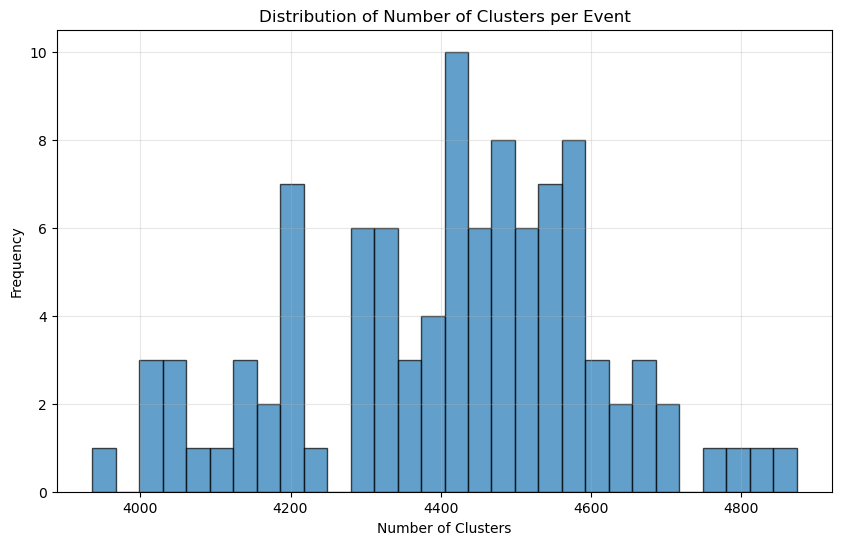

In [60]:
# ...existing code...
num_clusters_df = (calo
    .select('cluster_id', 'event_id')
    .with_columns(
        pl.col('cluster_id')
        .list.unique()
        .list.eval(pl.element().filter(pl.element() != -1))
        .list.len()
        .alias('num_clusters')
    )
    .drop('cluster_id')
)

plt.figure(figsize=(10, 6))
plt.hist(num_clusters_df['num_clusters'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Number of Clusters')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Clusters per Event')
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
calo_hits

event_id,detector,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times
u32,list[u8],list[f32],list[f32],list[f32],list[f32],list[list[u64]],list[list[f32]],list[list[f32]]
0,"[9, 10, … 12]","[0.000816, 0.000229, … 0.001104]","[202.36615, 142.800003, … -426.024139]","[296.12851, -1333.199951, … -383.597717]","[-3308.449951, 1071.0, … -3698.5]","[[140074], [176808], … [101665]]","[[0.000816], [0.000229], … [0.001104]]","[[11.255494], [6.272169], … [12.511644]]"
1,"[11, 11, … 10]","[0.000176, 0.000072, … 0.000057]","[-81.599998, -306.947235, … 288.261261]","[979.78894, -343.009705, … 1268.982788]","[3399.350098, 3293.300049, … 2315.399902]","[[63413], [37771], … [144414]]","[[0.000176], [0.000072], … [0.000057]]","[[13.390422], [11.420349], … [9.125679]]"
2,"[11, 9, … 9]","[0.000157, 0.001176, … 0.004281]","[449.388947, -1191.736206, … -588.234314]","[56.099998, 256.264709, … 458.409515]","[3389.25, -3257.949951, … -3237.75]","[[163748], [104990, 104993], … [165102, 165103, … 165130]]","[[0.000157], [0.000945, 0.00023], … [0.00082, 0.000162, … 0.000157]]","[[11.493533], [11.696384, 11.704118], … [10.595628, 10.589914, … 10.588522]]"
3,"[11, 10, … 11]","[0.000953, 0.000507, … 0.000152]","[174.848709, 820.349915, … 1199.088989]","[-728.641785, 1015.087158, … -5.1]","[3222.600098, 3014.100098, … 3343.800049]","[[169741, 169742], [126776], … [59272]]","[[0.000787, 0.000166], [0.000507], … [0.000152]]","[[10.912571, 10.908689], [11.580187], … [12.651039]]"
4,"[11, 9, … 9]","[0.000799, 0.000682, … 0.000127]","[119.866661, 685.602905, … -343.009705]","[-569.249512, 736.090332, … -321.372223]","[3263.0, -3247.850098, … -3207.449951]","[[120679, 183561], [212636], … [29980]]","[[0.000629, 0.00017], [0.000682], … [0.000127]]","[[11.394799, 10.772326], [13.429434], … [12.474256]]"
…,…,…,…,…,…,…,…,…
95,"[10, 11, … 9]","[0.000524, 0.000144, … 0.000449]","[1269.710938, 869.521423, … 498.078217]","[-603.214294, -602.659302, … 512.503174]","[-122.400002, 3202.399902, … -3379.149902]","[[67299], [51529], … [35885]]","[[0.000524], [0.000144], … [0.000449]]","[[5.378618], [11.371904], … [12.47866]]"
96,"[11, 11, … 14]","[0.000719, 0.000152, … 0.000754]","[-680.658081, -1239.327637, … 166.434967]","[-304.018616, 314.61911, … 323.415771]","[3424.600098, 3242.800049, … 3698.5]","[[181902], [254517], … [120056, 77062, 3540]]","[[0.000719], [0.000152], … [0.000014, 0.0007, 0.00004]]","[[11.49041], [12.142262], … [13.700319, 13.028481, 13.049866]]"
97,"[10, 10, … 10]","[0.000271, 0.000239, … 0.000442]","[45.900002, 870.766663, … -1206.436523]","[-1328.150024, 978.953979, … -505.242584]","[-1065.900024, 627.299988, … -459.0]","[[67378], [46416], … [186176]]","[[0.000271], [0.000239], … [0.000442]]","[[5.272822], [5.617964], … [6.149671]]"


In [61]:
from primary.interactive_plot import  plot_calo_clusters_interactive
plot_calo_clusters_interactive(calo, particles=particles.filter(pl.col("event_id") == 0), event_idx=0)

In [77]:
import polars as pl

def calculate_voxel_sizes_per_system(
    calo_hits: pl.DataFrame, 
    target_factors: dict[int, float]
) -> dict[int, float]:
    """
    Calculates the approximate voxel size for each detector system to achieve 
    specific reduction factors.
    
    Args:
        calo_hits: The input DataFrame.
        target_factors: A dictionary mapping {system_id: target_reduction_factor}.
                        Example: {1: 6.0, 2: 10.0}
    
    Returns:
        A dictionary mapping {system_id: optimal_voxel_size}.
    """
    
    # 1. Pre-process: Flatten everything once.
    # We need to associate x,y,z with their specific detector ID within the lists.
    print("Flattening data by detector system...")
    flat_all = (
        calo_hits
        .select(["event_id", "detector", "x", "y", "z"])
        .explode(["detector", "x", "y", "z"])
    )
    
    results = {}

    # 2. Iterate over each requested system
    for sys_id, target_reduction in target_factors.items():
        print(f"Processing System {sys_id} (Target Reduction: {target_reduction}x)...")
        
        # Filter hits strictly for this system
        sys_hits = flat_all.filter(pl.col("detector") == sys_id)
        
        if sys_hits.height == 0:
            print(f"Warning: No hits found for System {sys_id}. Skipping.")
            results[sys_id] = 0.0
            continue

        # Pre-calculate original counts per event for this system
        # (We only care about events that actually have hits in this system)
        orig_counts = (
            sys_hits
            .group_by("event_id")
            .len()
            .rename({"len": "orig_count"})
        )

        # Optimization Function
        def get_avg_reduction(voxel_size: float) -> float:
            if voxel_size <= 1e-6: return 1.0
            
            # A. Quantize to voxels
            # B. Unique per event (merges hits in same voxel)
            # C. Count new hits per event
            # D. Compare with original counts
            
            current_reduction = (
                sys_hits
                .with_columns([
                    (pl.col("x") / voxel_size).floor().cast(pl.Int32).alias("vx"),
                    (pl.col("y") / voxel_size).floor().cast(pl.Int32).alias("vy"),
                    (pl.col("z") / voxel_size).floor().cast(pl.Int32).alias("vz"),
                ])
                .unique(subset=["event_id", "vx", "vy", "vz"]) # The Voxelization step
                .group_by("event_id")
                .len()
                .rename({"len": "vox_count"})
                .join(orig_counts, on="event_id")
                .select(
                    (pl.col("orig_count") / pl.col("vox_count")).mean()
                )
                .item()
            )
            return current_reduction

        # Binary Search
        low, high = 0.1, 300.0 # Range in spatial units (e.g., mm)
        best_size = low
        
        # 15 iterations gives high precision for typical float coordinates
        for _ in range(12):
            mid = (low + high) / 2
            reduction = get_avg_reduction(mid)
            
            if reduction < target_reduction:
                # Not enough reduction -> make voxels bigger
                low = mid
            else:
                # Too much reduction -> make voxels smaller
                high = mid
            
            best_size = mid
            
        print(f"  -> Found size: {best_size:.4f} (Factor: {get_avg_reduction(best_size):.2f})")
        results[sys_id] = best_size

    return results

# ==========================================
# Example Usage
# ==========================================

# Define different targets for different systems
# System 10: wants 6x reduction
# System 20: wants 3x reduction
targets = {
    9: 6.0,
    10: 6.0,
    11: 6.0,
    12: 2.0,
    13: 2.0,
    14: 2.0,
}

# Calculate
optimal_sizes = calculate_voxel_sizes_per_system(calo_hits, targets)

print("\nFinal Configuration:")
print(optimal_sizes)

Flattening data by detector system...
Processing System 9 (Target Reduction: 6.0x)...
  -> Found size: 24.3351 (Factor: 5.94)
Processing System 10 (Target Reduction: 6.0x)...
  -> Found size: 58.6010 (Factor: 5.98)
Processing System 11 (Target Reduction: 6.0x)...
  -> Found size: 24.3351 (Factor: 5.93)
Processing System 12 (Target Reduction: 2.0x)...
  -> Found size: 60.2118 (Factor: 2.01)
Processing System 13 (Target Reduction: 2.0x)...
  -> Found size: 192.4431 (Factor: 2.00)
Processing System 14 (Target Reduction: 2.0x)...
  -> Found size: 60.2118 (Factor: 2.00)

Final Configuration:
{9: 24.3350830078125, 10: 58.601000976562496, 11: 24.3350830078125, 12: 60.2117919921875, 13: 192.4430908203125, 14: 60.2117919921875}


In [39]:
calo['x'][0]

""
f32
202.36615
142.800003
-76.5
-66.300003
444.121674
…
270.884796
-426.024139
-117.300003


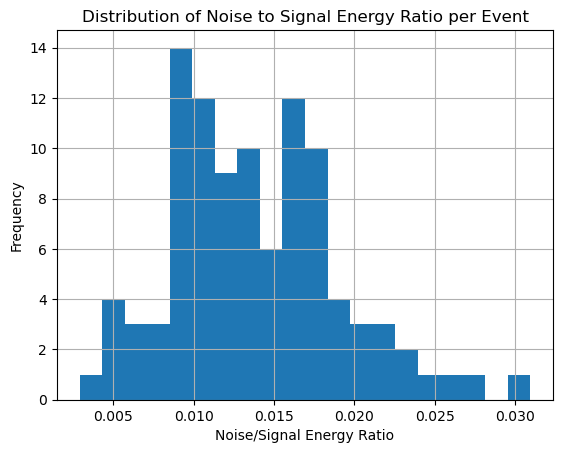

event_id,signal_energy,noise_energy,noise_signal_ratio
u32,f64,f64,f64
9,492.837286,9.343131,0.018958
12,1434.779559,14.435604,0.010061
3,642.87429,10.6613,0.016584
0,1048.78185,9.080605,0.008658
6,523.097852,8.436355,0.016128
…,…,…,…
92,422.969435,7.304851,0.01727
89,662.863191,6.672822,0.010067
86,2274.636179,10.023578,0.004407


In [62]:
# ...existing code...
# Prepare base query with common operations
base_query = (
    calo.lazy()
    .select('contrib_particle_ids', 'contrib_energies', 'event_id', 'cluster_id', 'detector')
    .explode('contrib_particle_ids', 'contrib_energies', 'cluster_id', 'detector')
    .explode('contrib_particle_ids', 'contrib_energies')
    .rename({'contrib_particle_ids':'particle_id', 'contrib_energies':'energy_contribution'})
    # Calibrate energy contributions
    .join(CALIBRATION.lazy(), on='detector')
    .with_columns((pl.col('energy_contribution') * pl.col('calib_factor')).alias('energy_contribution'))
    .join(
        particles.lazy()
        .select('event_id', 'particle_id','vertex_primary')
        .explode('particle_id','vertex_primary'), on=['event_id','particle_id'], how='inner'
    )
    .join(calo_deps_mappings.lazy(),
            left_on=['event_id','particle_id'], right_on=['event_id','src_particle_id'], how='inner'
        )
    .filter(pl.col('target_particle_id').is_not_null())
    .with_columns(pl.when(pl.col('vertex_primary') == 1).then(1).otherwise(0).alias('hard_scatter'))
    .filter(pl.col('hard_scatter') == 1)
)

# Calculate Signal Energy (cluster_id != -1)
signal_df = (
    base_query
    .filter(pl.col('cluster_id') != -1)
    .group_by('event_id')
    .agg(pl.col('energy_contribution').sum().alias('signal_energy'))
)

# Calculate Noise Energy (cluster_id == -1)
noise_df = (
    base_query
    .filter(pl.col('cluster_id') == -1)
    .group_by('event_id')
    .agg(pl.col('energy_contribution').sum().alias('noise_energy'))
)

# Join and ratio
final_df = (
    signal_df.join(noise_df, on='event_id', how='inner')
    .fill_null(0)
    .with_columns((pl.col('noise_energy') / (pl.col('signal_energy') + 1e-9)).alias('noise_signal_ratio'))
    .collect()
)
plt.hist(final_df['noise_signal_ratio'], bins=20)
plt.xlabel('Noise/Signal Energy Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Noise to Signal Energy Ratio per Event')
plt.grid(True)
plt.show()  
final_df

In [12]:
from primary.preprocessing import number_of_particles_per_cluster,number_of_clusters_per_particle
from primary.plot import plot_num_contributing_clusters,plot_num_contributing_ancestors

from primary.preprocessing import backtrack_to_target
target = (particles_hard_scatter.lazy()
        .select(['event_id','particle_id', 'is_target_particle'])
          .explode(['is_target_particle', 'particle_id'])
          .filter(pl.col('is_target_particle'))
          ).collect(streaming=True)
base  =(
        calo.lazy()
        .select(['event_id', 'contrib_particle_ids'])
        .explode('contrib_particle_ids')
        .explode('contrib_particle_ids') # Double explode if list[list]
        .rename({'contrib_particle_ids': 'particle_id'})
        .unique(subset=['event_id', 'particle_id'])
        .select([
            pl.col('event_id'),
            pl.col('particle_id').cast(pl.Int64)
        ])
    )
result = calo_deps_mappings

result = result.filter(pl.col('event_id').is_in(calo['event_id'].unique().implode()))
particles_to_pass = particles_hard_scatter.filter(pl.col('event_id').is_in(calo['event_id'].unique().implode()))
p = plot_num_contributing_ancestors(calo, result,particles=particles_to_pass, cut_off_percent=0.03, pt_cut=0.1, eta_cut=3.0)
c = plot_num_contributing_clusters(calo, result,particles=particles_to_pass,
                                     cut_off_percent=0.03, pt_cut=0.1, eta_cut=3.0)

/tmp/ipykernel_1295619/8723919.py:9: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


NameError: name 'calo_deps_mappings' is not defined

In [10]:
particles_to_pass

NameError: name 'particles_to_pass' is not defined

In [76]:
import gc
gc.collect()

0

In [23]:
def evaluate(calo: pl.DataFrame, calo_deps_mappings, particles_hard_scatter, cut_off_percent=0.01):
    # global context calo_deps_mappings, particles_hard_scatter
    from primary.preprocessing import number_of_clusters_per_particle
    c = number_of_clusters_per_particle(calo_hits_with_clusters=calo, ancestors=calo_deps_mappings, particles=particles_hard_scatter, cut_off_percent=cut_off_percent, pt_cut=0.1, eta_cut=3.0)
    return len(c.filter(pl.col('num_contributing_clusters') == 0)) / len(c)

In [ ]:
# Example usage:, evaluate(cut_off_percent=*)


event_id,particle_id,is_target_particle,pt,eta,ultimate_ancestor_id,num_contributing_clusters,max_ancestor_energy_deps_in_cluster
u32,u64,bool,f32,f32,i64,u32,f64
31,103,true,1.426738,-0.39117,103,1,3.363534
31,284,true,1.065756,-0.565283,284,2,0.78425
31,291,true,1.914563,1.251023,291,1,0.701991
31,316,true,0.393807,-1.058919,316,1,0.804146
31,377,true,0.4958,-1.360349,377,1,1.016302
…,…,…,…,…,…,…,…
14,263845,true,0.535931,-0.913805,263845,1,0.852396
14,263846,true,1.291263,-0.762149,263846,2,1.705137
14,263929,true,3.65082,-0.770559,263929,2,0.87695


Running evaluation for cut_off_values: [0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
cut_off=0, result=0.0048
cut_off=0.005, result=0.0195
cut_off=0.01, result=0.0364
cut_off=0.015, result=0.0545
cut_off=0.02, result=0.0674
cut_off=0.025, result=0.0807
cut_off=0.03, result=0.0927
cut_off=0.035, result=0.1028
cut_off=0.04, result=0.1130
cut_off=0.045, result=0.1232
cut_off=0.05, result=0.1334


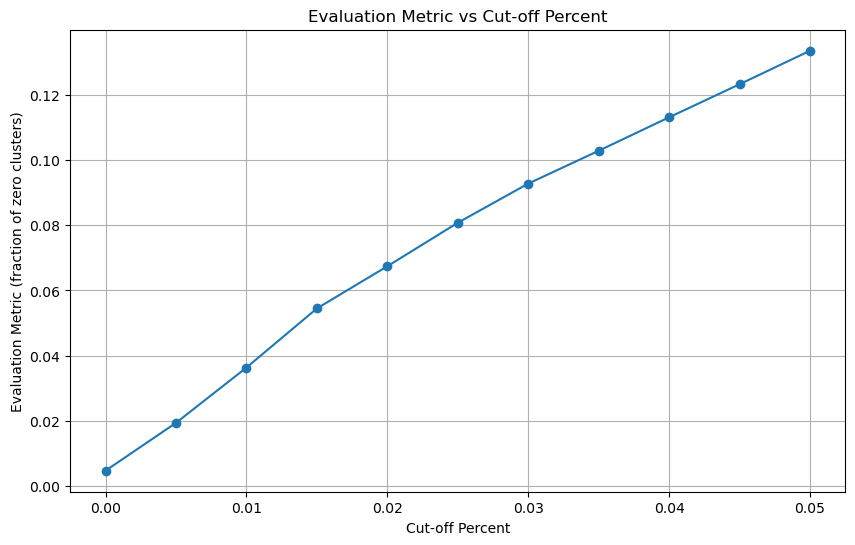

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of cut_off_percent values
# Range: 0, 0.01, 0.015, 0.02, ..., 0.05
# We can construct this as [0] + [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
cut_off_raw = [0]+[0.005] + [0.01 + i*0.005 for i in range(9)]
# clean up floating point if any
cut_off_values = [round(x, 4) for x in cut_off_raw]

results = []
print(f"Running evaluation for cut_off_values: {cut_off_values}")

for val in cut_off_values:
    # Call evaluate with the current cut_off_percent
    # Assuming calo, calo_deps_mappings, particles_hard_scatter are defined in previous cells
    res = evaluate(calo, calo_deps_mappings, particles_hard_scatter, cut_off_percent=val)
    results.append(res)
    print(f"cut_off={val}, result={res:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(cut_off_values, results, marker='o', linestyle='-')
plt.xlabel('Cut-off Percent')
plt.ylabel('Evaluation Metric (fraction of zero clusters)')
plt.title('Evaluation Metric vs Cut-off Percent')
plt.grid(True)
plt.show()

In [ ]:
calo['event_id'].unique()

AttributeError: 'Series' object has no attribute 'to_series'

In [29]:
from primary.multi_event_optimizer import MultiEventOptimizer
op = MultiEventOptimizer(calo_hits=calo_hits, max_events=20, max_clusters_penalty_threshold=5000
                         , n_trials=120, metric_fn=evaluate, calo_deps_mappings=calo_deps_mappings, particles_hard_scatter=particles_hard_scatter, seed=42)
op.optimize()

Preparing data for 20 events...
Voxelizing hits...


[I 2026-02-18 15:43:32,540] A new study created in memory with name: no-name-14e494bd-5b99-47c5-a65c-b68472fd768a


✓ Data prepared: 20 events
  Voxelized: 2883436 voxels, avg 144171 voxels/event
  Original:  16098915 hits, avg 804945 hits/event

Starting Optuna Optimization with 120 trials on 20 events...
Parameters: dc, rhoc, dm, ppbin (unified across all events)
Running CLUE with dc=87.45, rhoc=104.58, dm=146.78, ppbin=16 on 20 events...


[I 2026-02-18 15:43:42,825] Trial 0 finished with value: 0.11781206171107994 and parameters: {'dc': 87.45401188473625, 'rhoc': 104.57857370509078, 'dm': 146.78217777186447}. Best is trial 0 with value: 0.11781206171107994.


Running CLUE with dc=109.87, rhoc=17.16, dm=108.46, ppbin=16 on 20 events...


...

[I 2026-02-18 16:04:11,067] Trial 118 finished with value: 1.4196605890603087 and parameters: {'dc': 68.06001484201508, 'rhoc': 102.77908190438926, 'dm': 87.0307157172883}. Best is trial 91 with value: 0.04873772791023843.


Running CLUE with dc=71.88, rhoc=104.67, dm=89.86, ppbin=16 on 20 events...


[I 2026-02-18 16:04:21,598] Trial 119 finished with value: 0.6050238429172511 and parameters: {'dc': 71.88165258710144, 'rhoc': 104.66615535733739, 'dm': 89.86088432481299}. Best is trial 91 with value: 0.04873772791023843.



OPTIMIZATION FINISHED
Best Objective Value: 0.048738

Best Parameters:
  dc        : 75.88106168184893
  rhoc      : 104.34315216716726
  dm        : 87.0967630118376
  ppbin     : 16

FINAL EVALUATION (on all events)
Running CLUE with dc=75.88, rhoc=104.34, dm=87.10, ppbin=16 on 20 events...
Final Base Score Metric: 0.048738
Avg Clusters/Event:  4470.3
Range:               4057 - 4874


({'dc': 75.88106168184893,
  'rhoc': 104.34315216716726,
  'dm': 87.0967630118376,
  'ppbin': 16},
 <optuna.study.study.Study at 0x7fbdbb069e50>)

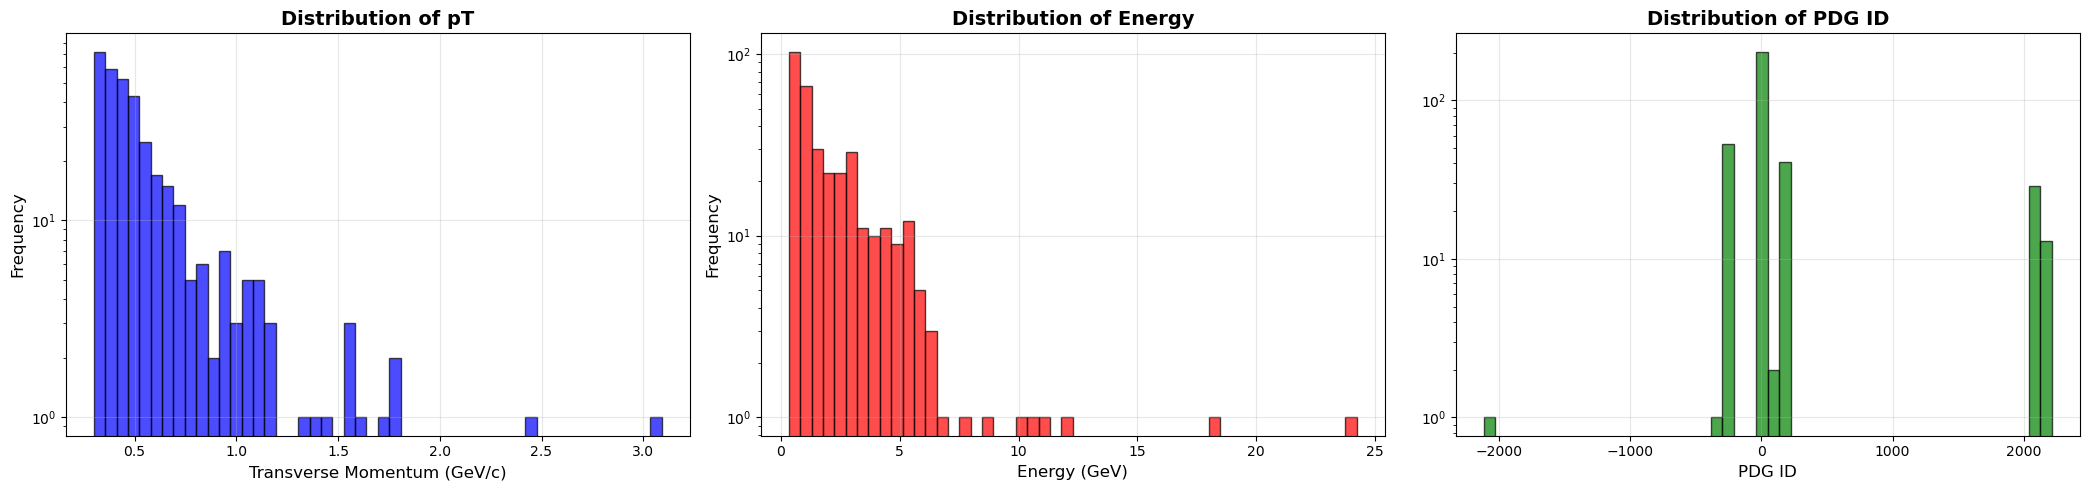


PT Statistics (from c_zeros):
  Count: 343
  Mean: 0.549
  Median: 0.450
  Min: 0.300
  Max: 3.090

Energy Statistics (from c_zeros):
  Count: 343
  Mean: 2.184
  Median: 1.300
  Min: 0.337
  Max: 24.221

PDG ID Statistics (from c_zeros):
  Count: 343
  Unique PDG IDs: 12
  Top 10 PDG IDs by frequency:
    PDG ID 22: 96 particles
    PDG ID 11: 56 particles
    PDG ID -211: 53 particles
    PDG ID -11: 48 particles
    PDG ID 211: 41 particles
    PDG ID 2112: 29 particles
    PDG ID 2212: 13 particles
    PDG ID 13: 2 particles
    PDG ID 130: 2 particles
    PDG ID -2112: 1 particles

Energy Sum Analysis:
  Sum Energy (Zero Clusters): 749.280
  Sum Energy (Non-Zero Clusters): 45319.684
  Ratio (Zero / Non-Zero): 0.016533


In [53]:
import matplotlib.pyplot as plt
import numpy as np
c_context = c.join(
    particles_hard_scatter.select(['event_id', 'particle_id', 'pdg_id', 'energy']).explode('particle_id','pdg_id', 'energy'),
    on=['event_id', 'particle_id'], how='inner'
)
c_zeros = c_context.filter(pl.col('num_contributing_clusters') == 0)
c_nonzeros = c_context.filter(pl.col('num_contributing_clusters') > 0)
# Create figure with three subplots based on c dataframe
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Histogram for pt from c
pt_data = c_zeros['pt'].to_numpy()
axes[0].hist(pt_data, bins=50, alpha=0.7, edgecolor='black', color='blue')
axes[0].set_xlabel('Transverse Momentum (GeV/c)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of pT', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Histogram for energy from c
energy_data = c_zeros['energy'].to_numpy()
axes[1].hist(energy_data, bins=50, alpha=0.7, edgecolor='black', color='red')
axes[1].set_xlabel('Energy (GeV)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Energy', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

# Histogram for pdg_id from c (if available, otherwise try from particles)
if 'pdg_id' in c_zeros.columns:
    pdg_ids = c_zeros['pdg_id'].to_numpy().astype(int)
else:
    raise ValueError("pdg_id column not found in c dataframe. Please ensure it is included in the join or available in the particles dataframe.")
axes[2].hist(pdg_ids, bins=50, alpha=0.7, edgecolor='black', color='green')
axes[2].set_xlabel('PDG ID', fontsize=12)
axes[2].set_title('Distribution of PDG ID', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nPT Statistics (from c_zeros):")
print(f"  Count: {len(pt_data)}")
print(f"  Mean: {np.mean(pt_data):.3f}")
print(f"  Median: {np.median(pt_data):.3f}")
print(f"  Min: {np.min(pt_data):.3f}")
print(f"  Max: {np.max(pt_data):.3f}")

print(f"\nEnergy Statistics (from c_zeros):")
print(f"  Count: {len(energy_data)}")
print(f"  Mean: {np.mean(energy_data):.3f}")
print(f"  Median: {np.median(energy_data):.3f}")
print(f"  Min: {np.min(energy_data):.3f}")
print(f"  Max: {np.max(energy_data):.3f}")

print(f"\nPDG ID Statistics (from c_zeros):")
print(f"  Count: {len(pdg_ids)}")
print(f"  Unique PDG IDs: {len(np.unique(pdg_ids))}")
print(f"  Top 10 PDG IDs by frequency:")
unique_pdg, counts = np.unique(pdg_ids, return_counts=True)
for pdg, count in sorted(zip(unique_pdg, counts), key=lambda x: x[1], reverse=True)[:10]:
    print(f"    PDG ID {pdg}: {count} particles")

# Calculate energy sums
energy_sum_zeros = c_zeros['energy'].sum()
energy_sum_nonzeros = c_nonzeros['energy'].sum()

print(f"\nEnergy Sum Analysis:")
print(f"  Sum Energy (Zero Clusters): {energy_sum_zeros:.3f}")
print(f"  Sum Energy (Non-Zero Clusters): {energy_sum_nonzeros:.3f}")
if energy_sum_nonzeros > 0:
    print(f"  Ratio (Zero / Non-Zero): {energy_sum_zeros / energy_sum_nonzeros:.6f}")
else:
    print(f"  Ratio (Zero / Non-Zero): Undefined (Non-Zero sum is 0)")